In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(r"C:\Users\USER\Documents\Retail-Perfomance-Engine\data\Superstore Sales Performance Analysis (Excel Project).csv")
df.head()

,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales,Performance
0,650,1989,2414,860,116320,High
1,869,1775,2104,980,105150,High
2,433,1365,1638,680,102920,High
3,409,1303,1587,1310,102310,High
4,759,1486,1758,820,101820,High


In [7]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 896 entries, 0 to 895
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Store ID              896 non-null    int64
 1   Store_Area            896 non-null    int64
 2   Items_Available       896 non-null    int64
 3   Daily_Customer_Count  896 non-null    int64
 4   Store_Sales           896 non-null    str  
 5   Performance           896 non-null    str  
dtypes: int64(4), str(2)
memory usage: 50.5 KB


,Store ID,Store_Area,Items_Available,Daily_Customer_Count
count,896.000000,896.000000,896.000000,896.000000
mean,448.500000,1485.409598,1782.035714,786.350446
std,258.797218,250.237011,299.872053,265.389281
min,1.000000,775.000000,932.000000,10.000000
25%,224.750000,1316.750000,1575.500000,600.000000
50%,448.500000,1477.000000,1773.500000,780.000000
75%,672.250000,1653.500000,1982.750000,970.000000
max,896.000000,2229.000000,2667.000000,1560.000000


In [8]:
df.isnull().sum()

Store ID                0
Store_Area              0
Items_Available         0
Daily_Customer_Count    0
Store_Sales             0
Performance             0
dtype: int64

In [9]:
df.corr(numeric_only=True)

,Store ID,Store_Area,Items_Available,Daily_Customer_Count
Store ID,1.000000,-0.058705,-0.055707,-0.010029
Store_Area,-0.058705,1.000000,0.998891,-0.041423
Items_Available,-0.055707,0.998891,1.000000,-0.040978
Daily_Customer_Count,-0.010029,-0.041423,-0.040978,1.000000


In [ ]:
# --- Feature Engineering ---

In [19]:
#sales efficiency per customer
df["sales_per_customer"] = df["Store_Sales"] / df["Daily_Customer_Count"]
#how much each customer is worth

In [20]:
#space efficiency
df["sales_per_area"] = df["Store_Sales"] / df["Store_Area"]

In [21]:
#inventory density
df["items_per_area"] = df["Items_Available"] / df["Store_Area"]

In [22]:
#inventory efficiency
df["sales_per_item"] = df["Store_Sales"] / df["Items_Available"]
#Are the products actually generating revenue?

In [11]:
#handle any potential infinite values from division by zero
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna

<bound method DataFrame.dropna of      Store ID   Store_Area  Items_Available  Daily_Customer_Count Store_Sales  \
0          650        1989             2414                   860      116320   
1          869        1775             2104                   980      105150   
2          433        1365             1638                   680      102920   
3          409        1303             1587                  1310      102310   
4          759        1486             1758                   820      101820   
..         ...         ...              ...                   ...         ...   
891        353        1397             1686                   850       21300   
892        594        1624             1946                   870       20270   
893        776        1537             1877                   660       17670   
894        853        1477             1790                   880       16370   
895         32        1250             1508                   990       149

In [ ]:
#validate the new features

In [12]:
df.head()

,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales,Performance
0,650,1989,2414,860,116320,High
1,869,1775,2104,980,105150,High
2,433,1365,1638,680,102920,High
3,409,1303,1587,1310,102310,High
4,759,1486,1758,820,101820,High


In [13]:
df.describe()

,Store ID,Store_Area,Items_Available,Daily_Customer_Count
count,896.000000,896.000000,896.000000,896.000000
mean,448.500000,1485.409598,1782.035714,786.350446
std,258.797218,250.237011,299.872053,265.389281
min,1.000000,775.000000,932.000000,10.000000
25%,224.750000,1316.750000,1575.500000,600.000000
50%,448.500000,1477.000000,1773.500000,780.000000
75%,672.250000,1653.500000,1982.750000,970.000000
max,896.000000,2229.000000,2667.000000,1560.000000


In [16]:
df["Store_Sales"] = pd.to_numeric(df["Store_Sales"], errors="coerce")
df["Store_Area"] = pd.to_numeric(df["Store_Area"], errors="coerce")
df["Items_Available"] = pd.to_numeric(df["Items_Available"], errors="coerce")
df["Daily_Customer_Count"] = pd.to_numeric(df["Daily_Customer_Count"], errors="coerce")

In [ ]:
#remove bad rows
df.dropna(inplace=True)

In [18]:
df.dtypes

Store ID                  int64
Store_Area                int64
Items_Available           int64
Daily_Customer_Count      int64
Store_Sales             float64
Performance                 str
dtype: object

In [ ]:
#Intelligence layer
# The model

In [23]:
#define the modelling target
# features for baseline model (start simple)
features = ["Store_Area", "Items_Available", "Daily_Customer_Count"]

X = df[features]
y = df["Store_Sales"]

In [24]:
#Training the model and evaluating it
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))
#MAE - average error in currency units
#R2 - how much of the variance in sales is explained by the model

MAE: 14613.337177672394
R2: -0.01226925969065995


In [25]:
#the performance gap (core metric for the engine)
df["predicted_sales"] = model.predict(X)
df["performance_gap"] = df["Store_Sales"] - df["predicted_sales"]

In [26]:
#classify store performance
df["performance_label"] = df["performance_gap"].apply(
    lambda x: "Underperforming" if x < 0 else "Overperforming"
)

In [27]:
#diagnose the WHY - feature importance
def diagnose(row):
    if row["Daily_Customer_Count"] > df["Daily_Customer_Count"].median() and row["sales_per_customer"] < df["sales_per_customer"].median():
        return "Low conversion (traffic not converting)"
    
    if row["Store_Area"] > df["Store_Area"].median() and row["sales_per_area"] < df["sales_per_area"].median():
        return "Inefficient space usage"
    
    if row["Items_Available"] > df["Items_Available"].median() and row["sales_per_item"] < df["sales_per_item"].median():
        return "Weak product mix"
    
    return "Balanced / No major issue"

df["diagnosis"] = df.apply(diagnose, axis=1)

In [28]:
#rank stores
df_sorted = df.sort_values(by="performance_gap")
df_sorted.head(10)   # worst performers
df_sorted.tail(10)   # best performers

,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales,Performance,sales_per_customer,sales_per_area,items_per_area,sales_per_item,predicted_sales,performance_gap,performance_label,diagnosis
8,693,1548,1858,480,99480.0,High,207.250000,64.263566,1.200258,53.541442,59767.678404,39712.321596,Overperforming,Balanced / No major issue
7,167,1465,1763,680,99570.0,High,146.426471,67.965870,1.203413,56.477595,59226.222814,40343.777186,Overperforming,Balanced / No major issue
10,469,1060,1279,670,97360.0,High,145.313433,91.849057,1.206604,76.121970,55838.329021,41521.670979,Overperforming,Balanced / No major issue
6,867,1565,1854,900,100900.0,High,112.111111,64.472843,1.184665,54.422869,59236.722593,41663.277407,Overperforming,Balanced / No major issue
4,759,1486,1758,820,101820.0,High,124.170732,68.519515,1.183042,57.918089,58517.682862,43302.317138,Overperforming,Balanced / No major issue
3,409,1303,1587,1310,102310.0,High,78.099237,78.518803,1.217959,64.467549,58484.265597,43825.734403,Overperforming,Balanced / No major issue
1,869,1775,2104,980,105150.0,High,107.295918,59.239437,1.185352,49.976236,60974.567670,44175.432330,Overperforming,Balanced / No major issue
2,433,1365,1638,680,102920.0,High,151.352941,75.399267,1.200000,62.832723,58225.212366,44694.787634,Overperforming,Balanced / No major issue
5,558,1137,1374,700,101780.0,High,145.400000,89.516271,1.208443,74.075691,56575.634708,45204.365292,Overperforming,Balanced / No major issue
0,650,1989,2414,860,116320.0,High,135.255814,58.481649,1.213675,48.185584,64375.689998,51944.310002,Overperforming,Balanced / No major issue


In [29]:
#validate signal strength
import pandas as pd

importance = pd.Series(model.coef_, index=features)
importance.sort_values(ascending=False)

Items_Available         30.001881
Daily_Customer_Count     0.134333
Store_Area             -27.492247
dtype: float64

In [ ]:
#Visualization Layers

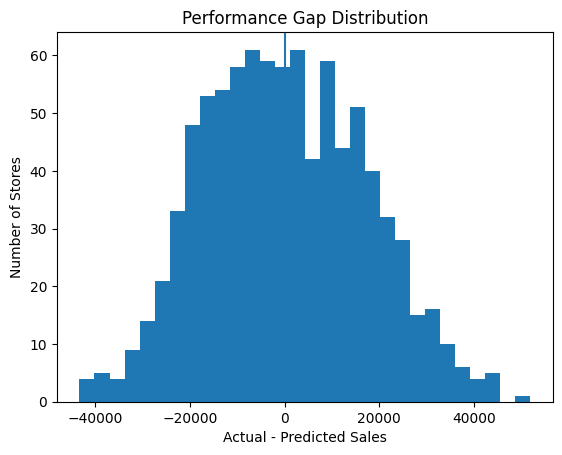

In [30]:
plt.figure()
plt.hist(df["performance_gap"], bins=30)
plt.axvline(0)
plt.title("Performance Gap Distribution")
plt.xlabel("Actual - Predicted Sales")
plt.ylabel("Number of Stores")
plt.show()

#Distribution of performance gaps across stores
#Left of 0 → underperforming
#Right of 0 → outperforming
#Width → how severe deviations are

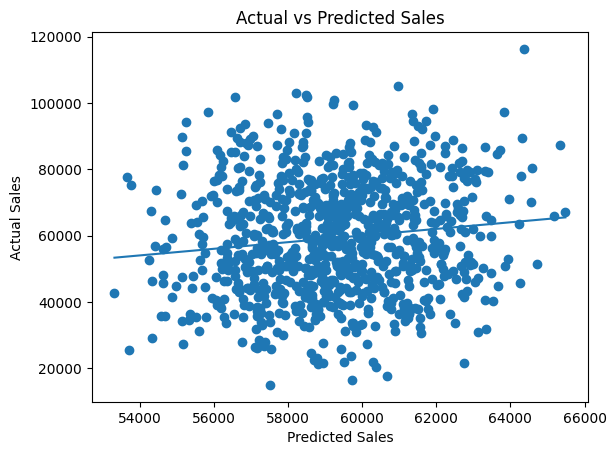

In [31]:
#Predicted vs Actual Sales
#Points below the diagonal line → underperforming
#Distance from line = severity
plt.figure()
plt.scatter(df["predicted_sales"], df["Store_Sales"])
plt.plot([df["predicted_sales"].min(), df["predicted_sales"].max()],
         [df["predicted_sales"].min(), df["predicted_sales"].max()])
plt.title("Actual vs Predicted Sales")
plt.xlabel("Predicted Sales")
plt.ylabel("Actual Sales")
plt.show()

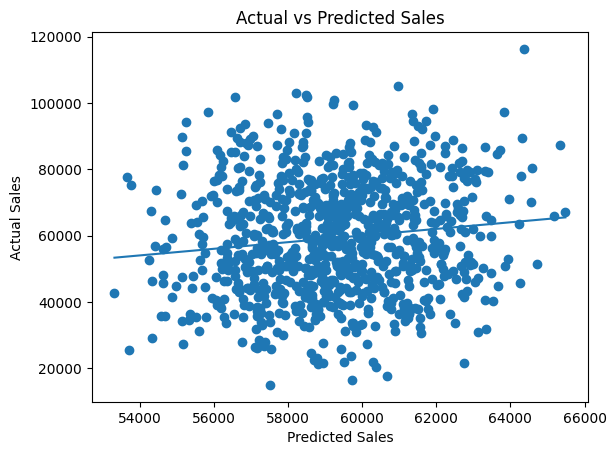

In [32]:
#Worst stores
#Most negative values = highest priority problems
plt.figure()
plt.scatter(df["predicted_sales"], df["Store_Sales"])
plt.plot([df["predicted_sales"].min(), df["predicted_sales"].max()],
         [df["predicted_sales"].min(), df["predicted_sales"].max()])
plt.title("Actual vs Predicted Sales")
plt.xlabel("Predicted Sales")
plt.ylabel("Actual Sales")
plt.show()

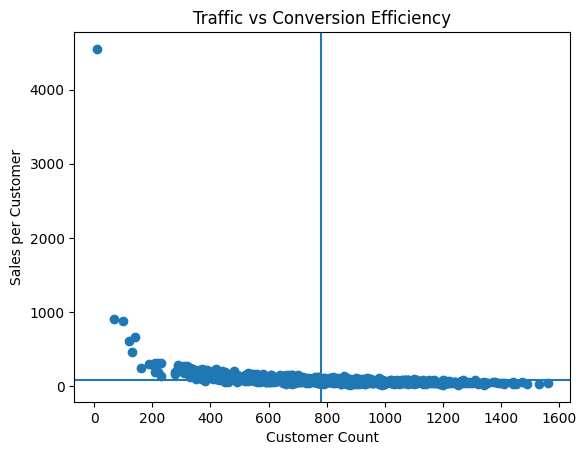

In [33]:
#efficiency vs traffic
plt.figure()
plt.scatter(df["Daily_Customer_Count"], df["sales_per_customer"])
plt.axhline(df["sales_per_customer"].median())
plt.axvline(df["Daily_Customer_Count"].median())
plt.title("Traffic vs Conversion Efficiency")
plt.xlabel("Customer Count")
plt.ylabel("Sales per Customer")
plt.show()
#High traffic + low efficiency → conversion issue
#Low traffic + high efficiency → marketing opportunity
#Low/low → weak store
#High/high → best performers

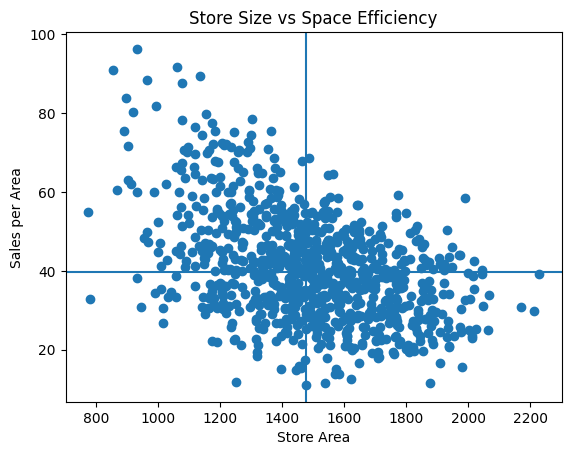

In [34]:
#Space efficiency
plt.figure()
plt.scatter(df["Store_Area"], df["sales_per_area"])
plt.axhline(df["sales_per_area"].median())
plt.axvline(df["Store_Area"].median())
plt.title("Store Size vs Space Efficiency")
plt.xlabel("Store Area")
plt.ylabel("Sales per Area")
plt.show()
#Large store + low efficiency → wasted space
#Small store + high efficiency → scalable model

In [35]:
#Simple summary KPI
underperforming_rate = (df["performance_gap"] < 0).mean() * 100
print(f"Underperforming Stores: {underperforming_rate:.2f}%")

Underperforming Stores: 52.07%


In [38]:
import os

BASE_DIR = os.path.abspath("..")   # project root
model_path = os.path.join(BASE_DIR, "src", "model.pkl")

os.makedirs(os.path.dirname(model_path), exist_ok=True)

with open(model_path, "wb") as f:
    pickle.dump(model, f)

In [39]:
import pickle

with open("../src/model.pkl", "wb") as f:
    pickle.dump(model, f)

In [42]:
df = pd.read_csv("C:\\Users\\USER\\Documents\\Retail-Perfomance-Engine\\data\\Superstore Sales Performance Analysis (Excel Project).csv")

In [43]:
import os
import pickle

base = os.getcwd()  # current notebook folder
project_root = os.path.dirname(base)

model_path = os.path.join(project_root, "src", "model.pkl")
os.makedirs(os.path.dirname(model_path), exist_ok=True)

with open(model_path, "wb") as f:
    pickle.dump(model, f)

print("Saved to:", model_path)

Saved to: C:\Users\USER\Documents\src\model.pkl


In [44]:
os.path.exists("../src/model.pkl")

True

In [45]:
import os
print(os.path.abspath("../src/model.pkl"))

C:\Users\USER\Documents\src\model.pkl


In [46]:
import os

PROJECT_ROOT = os.path.abspath("..")
MODEL_PATH = os.path.join(PROJECT_ROOT, "src", "model.pkl")

print(PROJECT_ROOT)
print(MODEL_PATH)

C:\Users\USER\Documents
C:\Users\USER\Documents\src\model.pkl


In [47]:
import os
print(os.listdir(os.path.join(PROJECT_ROOT, "src")))

['model.pkl']


In [48]:
import pickle

model = pickle.load(open(MODEL_PATH, "rb"))

In [50]:
import os
import pickle

# go to project root from notebooks/
PROJECT_ROOT = os.path.abspath("..")

MODEL_PATH = os.path.join(PROJECT_ROOT, "src", "model.pkl")

os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

with open(MODEL_PATH, "wb") as f:
    pickle.dump(model, f)

print("Saved to:", MODEL_PATH)

Saved to: C:\Users\USER\Documents\src\model.pkl
